# Análisis y Tratamiento Digital de Imágenes Satelitales: TP1

## 1. Descarga de Imágen Landsat 8

In [ ]:
pip install rasterio matplotlib

In [2]:
from __future__ import annotations
import os
import numpy as np
from PIL import Image
import matplotlib
# matplotlib.use("Agg") # Removed to allow plots to display in the notebook
import matplotlib.pyplot as plt
import requests
import io
from PIL import Image
from io import BytesIO
from IPython.display import display

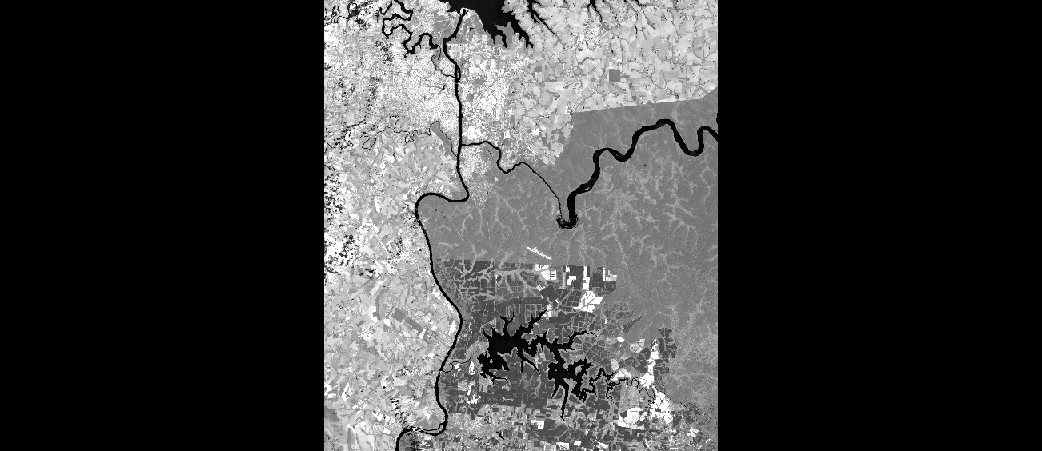

In [3]:
url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales/refs/heads/main/LC08_224-078_2018-01-05_swir1.jpg"

response = requests.get(url)

img = Image.open(BytesIO(response.content))

display(img)

## 2. Implementar un programa que realice las siguientes operaciones con imágenes cualquier formato (raw, pgm, ppm, jpg) y una imagen satelital óptica:


Imagen original:


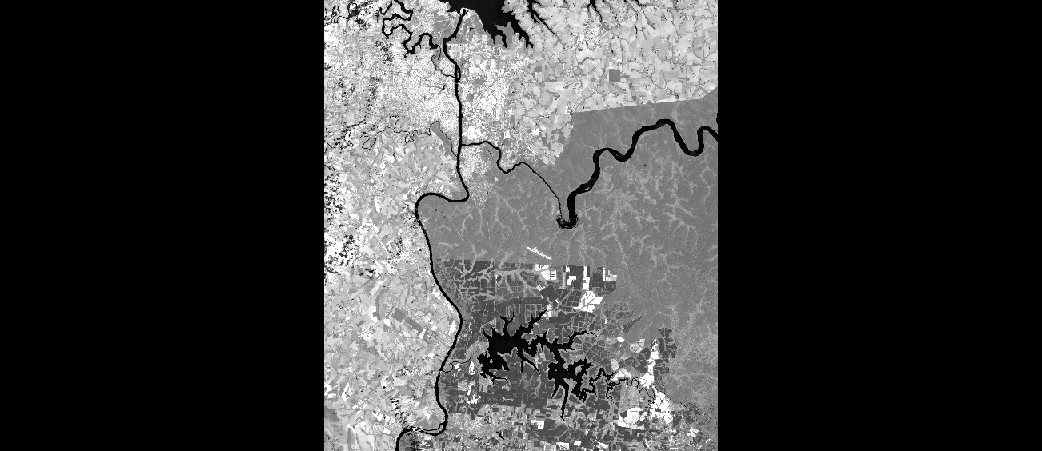

Imagen guardada como: swir1_guardada.jpg
Valor del pixel:
(0, 0, 0)
Imagen cortada:


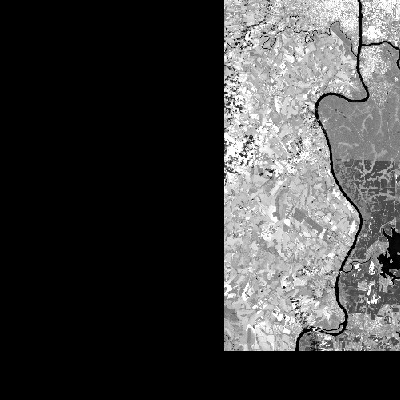

Imagen cortada guardada como: swir1_cortada.jpg


In [4]:
# ============================================
# TRATAMIENTO DIGITAL DE IMÁGENES
# Imagen satelital Landsat - SWIR1
# ============================================

from PIL import Image
from io import BytesIO
import requests
import numpy as np
from IPython.display import display


# --------------------------------------------
# a) Cargar una imagen y desplegarla
# --------------------------------------------

url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales/refs/heads/main/LC08_224-078_2018-01-05_swir1.jpg"

response = requests.get(url)

img = Image.open(BytesIO(response.content))

print("Imagen original:")
display(img)


# --------------------------------------------
# b) Guardar una imagen a un archivo
# --------------------------------------------

img.save("swir1_guardada.jpg")

print("Imagen guardada como: swir1_guardada.jpg")


# --------------------------------------------
# c) Obtener el valor de un pixel
# --------------------------------------------

# Coordenadas del pixel
x = 100
y = 100

pixel = img.getpixel((x, y))

print("Valor del pixel:")
print(pixel)


# --------------------------------------------
# d) Copiar una parte de la imagen
#    en una imagen nueva
# --------------------------------------------

# Definir área de corte
x1 = 100
y1 = 100
x2 = 500
y2 = 500

imagen_cortada = img.crop((x1, y1, x2, y2))

print("Imagen cortada:")
display(imagen_cortada)


# --------------------------------------------
# e) Guardar la imagen cortada
#    con otro nombre
# --------------------------------------------

imagen_cortada.save("swir1_cortada.jpg")

print("Imagen cortada guardada como: swir1_cortada.jpg")

## 3. Implementar la función de potencia γ, 0 < γ < 2 y γ̸ = 1 y aplicarla a una imagen en niveles de gris. Variar el valor de γ para observar los resultados.

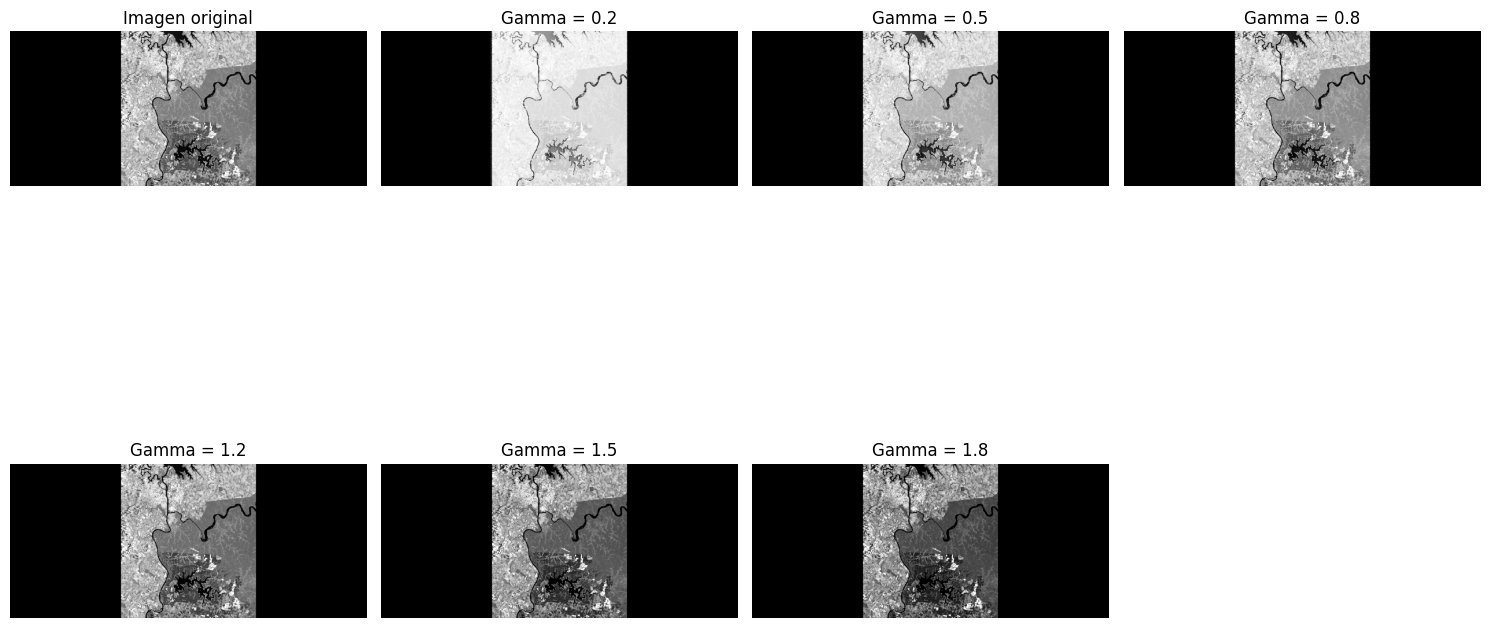

Guardada: swir1_gamma_0.2.jpg
Guardada: swir1_gamma_0.5.jpg
Guardada: swir1_gamma_0.8.jpg
Guardada: swir1_gamma_1.2.jpg
Guardada: swir1_gamma_1.5.jpg
Guardada: swir1_gamma_1.8.jpg


In [5]:
# ============================================================
# 3. TRANSFORMACIÓN DE POTENCIA GAMMA
# ============================================================

# ------------------------------------------------------------
# 1. Convertir la imagen a niveles de gris
# ------------------------------------------------------------

img_gris = img.convert("L")

# ------------------------------------------------------------
# 2. Implementar función de potencia Gamma
# ------------------------------------------------------------

def potencia_gamma(imagen, gamma):

    # Convertir imagen a matriz NumPy
    img_array = np.array(imagen).astype(np.float32)

    # Normalizar valores de 0-255 a 0-1
    img_normalizada = img_array / 255.0

    # Aplicar transformación de potencia
    img_gamma = img_normalizada ** gamma

    # Volver a escala 0-255
    img_gamma = img_gamma * 255

    # Asegurar valores dentro del rango válido
    img_gamma = np.clip(img_gamma, 0, 255).astype(np.uint8)

    # Convertir nuevamente a imagen
    return Image.fromarray(img_gamma)

# ------------------------------------------------------------
# 3. Valores de Gamma a probar
# ------------------------------------------------------------

gammas = [0.2, 0.5, 0.8, 1.2, 1.5, 1.8]

# ------------------------------------------------------------
# 4. Mostrar imagen original y resultados
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

# Imagen original
plt.subplot(2, 4, 1)
plt.imshow(img_gris, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

# Aplicar diferentes valores de Gamma
for i, gamma in enumerate(gammas):

    resultado = potencia_gamma(img_gris, gamma)

    plt.subplot(2, 4, i + 2)
    plt.imshow(resultado, cmap="gray")
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Guardar los resultados
# ------------------------------------------------------------

for gamma in gammas:

    resultado = potencia_gamma(img_gris, gamma)

    nombre = f"swir1_gamma_{gamma}.jpg"

    resultado.save(nombre)

    print(f"Guardada: {nombre}")

## 4. Implementar una función que devuelva el negativo de una imagen y aplicarlo a una imagen RGB banda por banda.


/tmp/ipykernel_8200/2503360632.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(negativo.astype(np.uint8), mode="RGB")


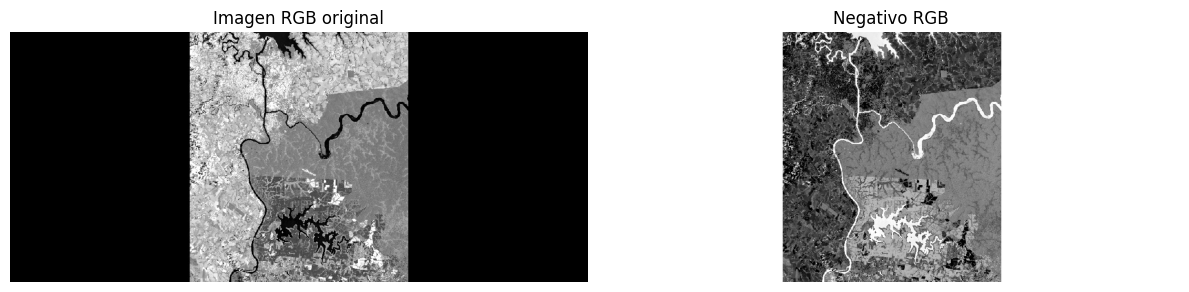

Imagen negativa guardada como: swir1_negativo_rgb.jpg


In [6]:
# ============================================================
# 4. NEGATIVO DE UNA IMAGEN RGB BANDA POR BANDA
# ============================================================

# ------------------------------------------------------------
# 1. Función para obtener el negativo
# ------------------------------------------------------------

def negativo_rgb(imagen):

    # Convertir imagen a matriz NumPy
    img_array = np.array(imagen).astype(np.uint8)

    # Separar las bandas R, G y B
    R = img_array[:, :, 0]
    G = img_array[:, :, 1]
    B = img_array[:, :, 2]

    # Aplicar negativo banda por banda
    R_neg = 255 - R
    G_neg = 255 - G
    B_neg = 255 - B

    # Unir nuevamente las tres bandas
    negativo = np.stack((R_neg, G_neg, B_neg), axis=2)

    # Convertir a imagen RGB
    return Image.fromarray(negativo.astype(np.uint8), mode="RGB")


# ------------------------------------------------------------
# 2. Aplicar el negativo
# ------------------------------------------------------------

img_negativa = negativo_rgb(img)

# ------------------------------------------------------------
# 3. Mostrar imagen original y negativo
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Imagen RGB original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_negativa)
plt.title("Negativo RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Guardar la imagen negativa
# ------------------------------------------------------------

img_negativa.save("swir1_negativo_rgb.jpg")

print("Imagen negativa guardada como: swir1_negativo_rgb.jpg")

## 5. Implememtar una función que devuelva el histograma de niveles de gris de cada banda de una imagen.


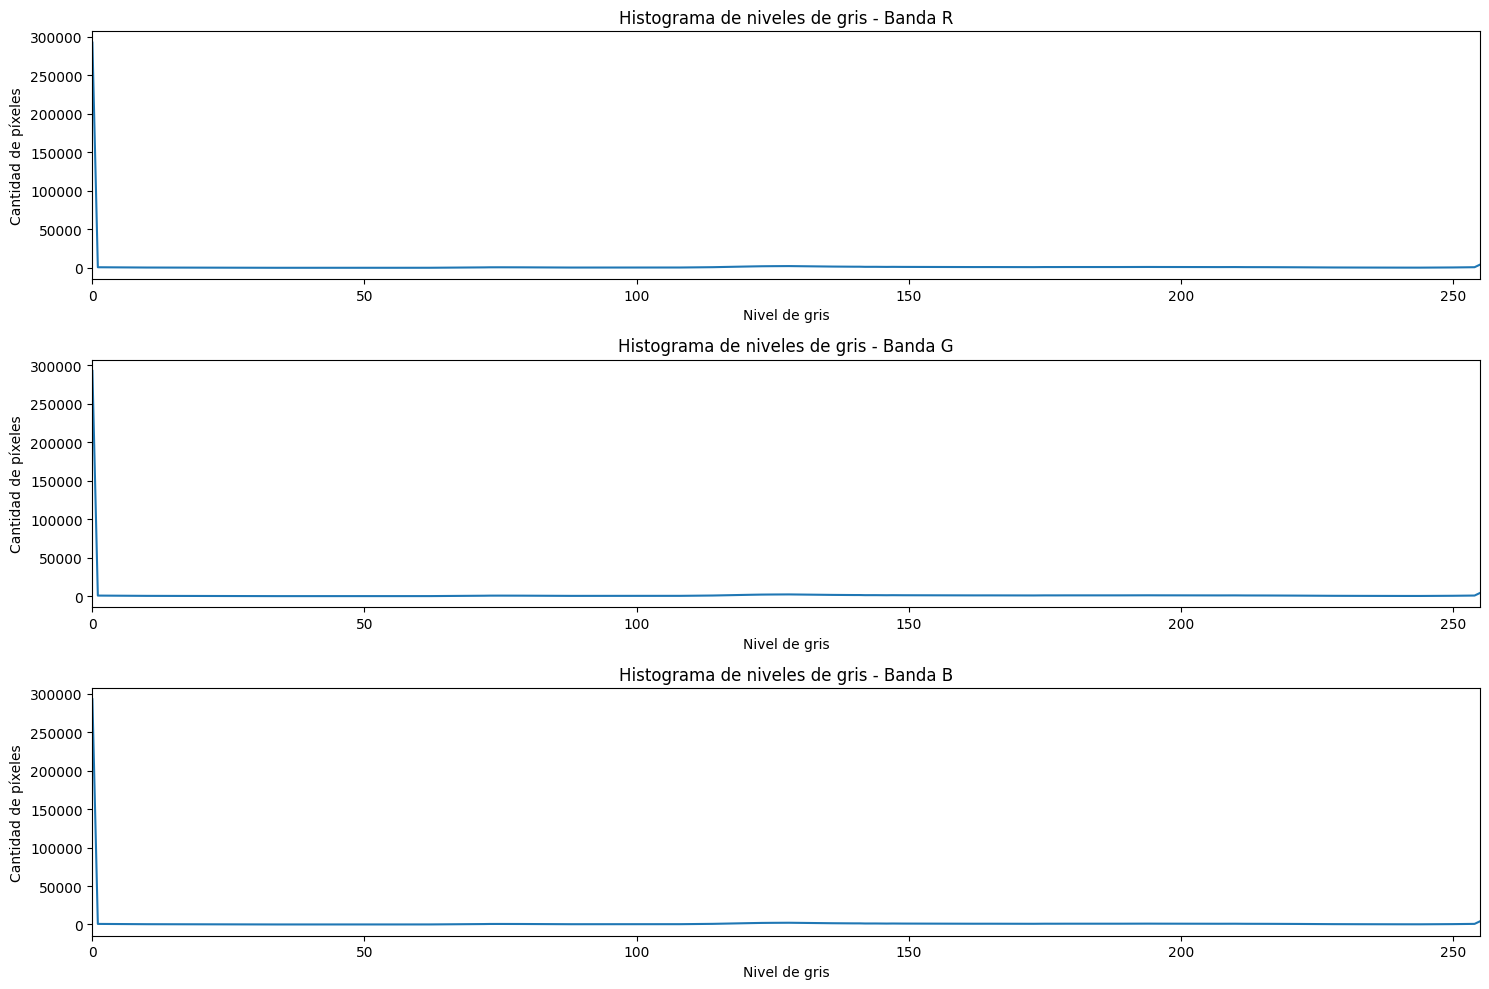

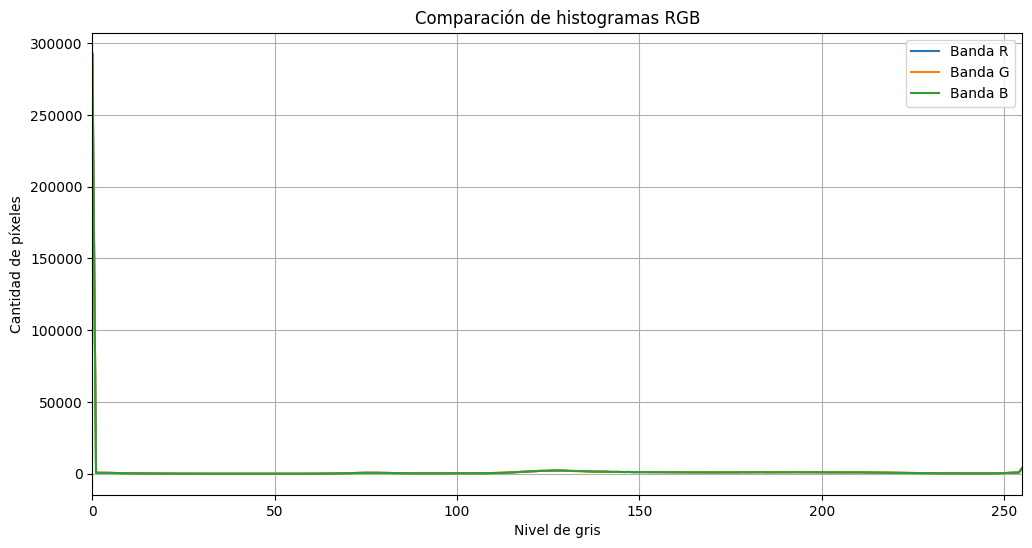

In [7]:
# ============================================================
# 5. HISTOGRAMA DE NIVELES DE GRIS DE CADA BANDA
# ============================================================

# ------------------------------------------------------------
# 1. Función para obtener el histograma de una banda
# ------------------------------------------------------------

def histograma_banda(banda):

    # Convertir la banda a una matriz NumPy
    datos = np.array(banda)

    # Crear histograma de 256 niveles (0-255)
    histograma = np.bincount(datos.ravel(), minlength=256)

    return histograma


# ------------------------------------------------------------
# 2. Separar las bandas RGB
# ------------------------------------------------------------

R = img.getchannel("R")
G = img.getchannel("G")
B = img.getchannel("B")


# ------------------------------------------------------------
# 3. Obtener histogramas de cada banda
# ------------------------------------------------------------

hist_R = histograma_banda(R)
hist_G = histograma_banda(G)
hist_B = histograma_banda(B)


# ------------------------------------------------------------
# 4. Mostrar los histogramas
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

# Histograma banda R
plt.subplot(3, 1, 1)
plt.plot(range(256), hist_R)
plt.title("Histograma de niveles de gris - Banda R")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)

# Histograma banda G
plt.subplot(3, 1, 2)
plt.plot(range(256), hist_G)
plt.title("Histograma de niveles de gris - Banda G")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)

# Histograma banda B
plt.subplot(3, 1, 3)
plt.plot(range(256), hist_B)
plt.title("Histograma de niveles de gris - Banda B")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Mostrar los histogramas juntos para comparar
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(range(256), hist_R, label="Banda R")
plt.plot(range(256), hist_G, label="Banda G")
plt.plot(range(256), hist_B, label="Banda B")

plt.title("Comparación de histogramas RGB")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)
plt.legend()
plt.grid()

plt.show()

## 6. Implementar una función que aplique un umbral a cada banda de una imagen, devolviendo una imagen binaria para cada una.

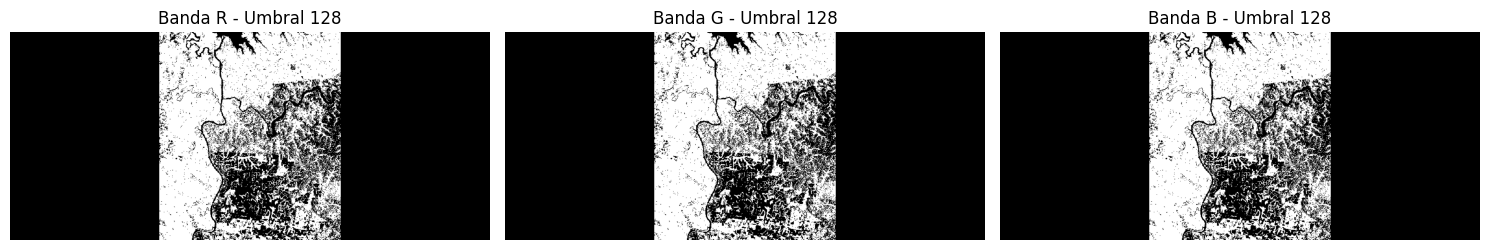

Imágenes binarias guardadas:
- banda_R_binaria.jpg
- banda_G_binaria.jpg
- banda_B_binaria.jpg


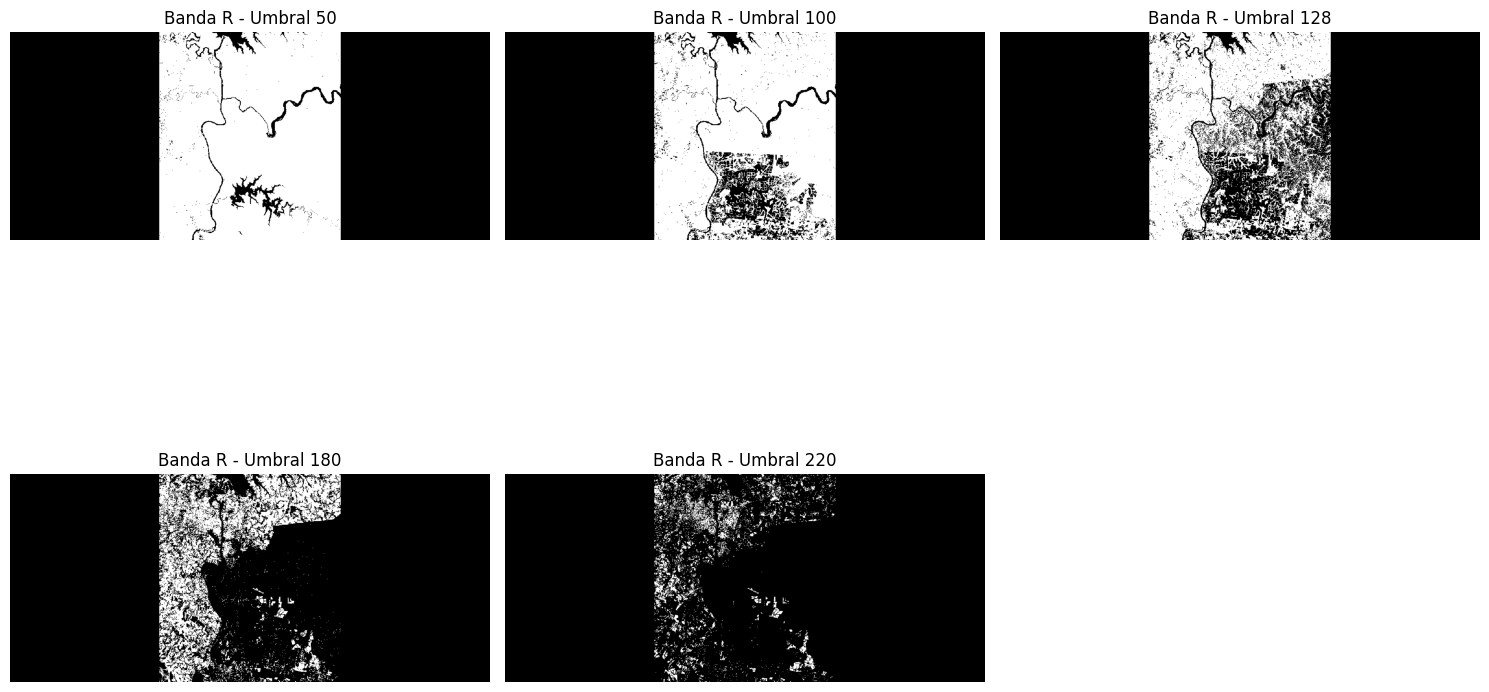

In [8]:
# ============================================================
# 6. UMBRALIZACIÓN DE CADA BANDA DE UNA IMAGEN RGB
# ============================================================

# ------------------------------------------------------------
# 1. Función para aplicar umbral
# ------------------------------------------------------------

def aplicar_umbral(banda, umbral):

    # Convertir la banda a una matriz NumPy
    datos = np.array(banda)

    # Aplicar el umbral
    imagen_binaria = np.where(datos >= umbral, 255, 0)

    # Convertir nuevamente a imagen
    return Image.fromarray(imagen_binaria.astype(np.uint8))


# ------------------------------------------------------------
# 2. Separar las bandas RGB
# ------------------------------------------------------------

R = img.getchannel("R")
G = img.getchannel("G")
B = img.getchannel("B")


# ------------------------------------------------------------
# 3. Definir el umbral
# ------------------------------------------------------------

umbral = 128


# ------------------------------------------------------------
# 4. Aplicar umbral a cada banda
# ------------------------------------------------------------

R_binaria = aplicar_umbral(R, umbral)
G_binaria = aplicar_umbral(G, umbral)
B_binaria = aplicar_umbral(B, umbral)


# ------------------------------------------------------------
# 5. Mostrar las imágenes binarias
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(R_binaria, cmap="gray")
plt.title(f"Banda R - Umbral {umbral}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(G_binaria, cmap="gray")
plt.title(f"Banda G - Umbral {umbral}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(B_binaria, cmap="gray")
plt.title(f"Banda B - Umbral {umbral}")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Guardar las imágenes binarias
# ------------------------------------------------------------

R_binaria.save("banda_R_binaria.jpg")
G_binaria.save("banda_G_binaria.jpg")
B_binaria.save("banda_B_binaria.jpg")

print("Imágenes binarias guardadas:")
print("- banda_R_binaria.jpg")
print("- banda_G_binaria.jpg")
print("- banda_B_binaria.jpg")


# ------------------------------------------------------------
# 7. Probar diferentes valores de umbral
# ------------------------------------------------------------

umbrales = [50, 100, 128, 180, 220]

plt.figure(figsize=(15, 10))

for i, T in enumerate(umbrales):

    resultado = aplicar_umbral(R, T)

    plt.subplot(2, 3, i + 1)
    plt.imshow(resultado, cmap="gray")
    plt.title(f"Banda R - Umbral {T}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Implementar una función que realice la ecualización del histograma para mejorar la imagen, realizar la operación banda por banda, observar los resultados.

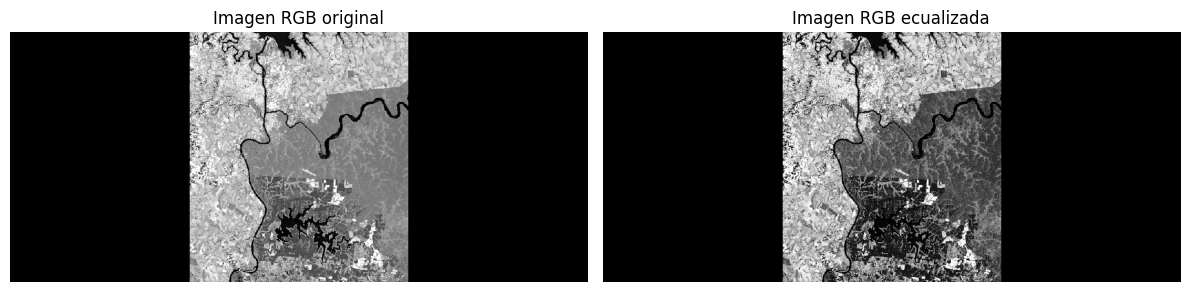

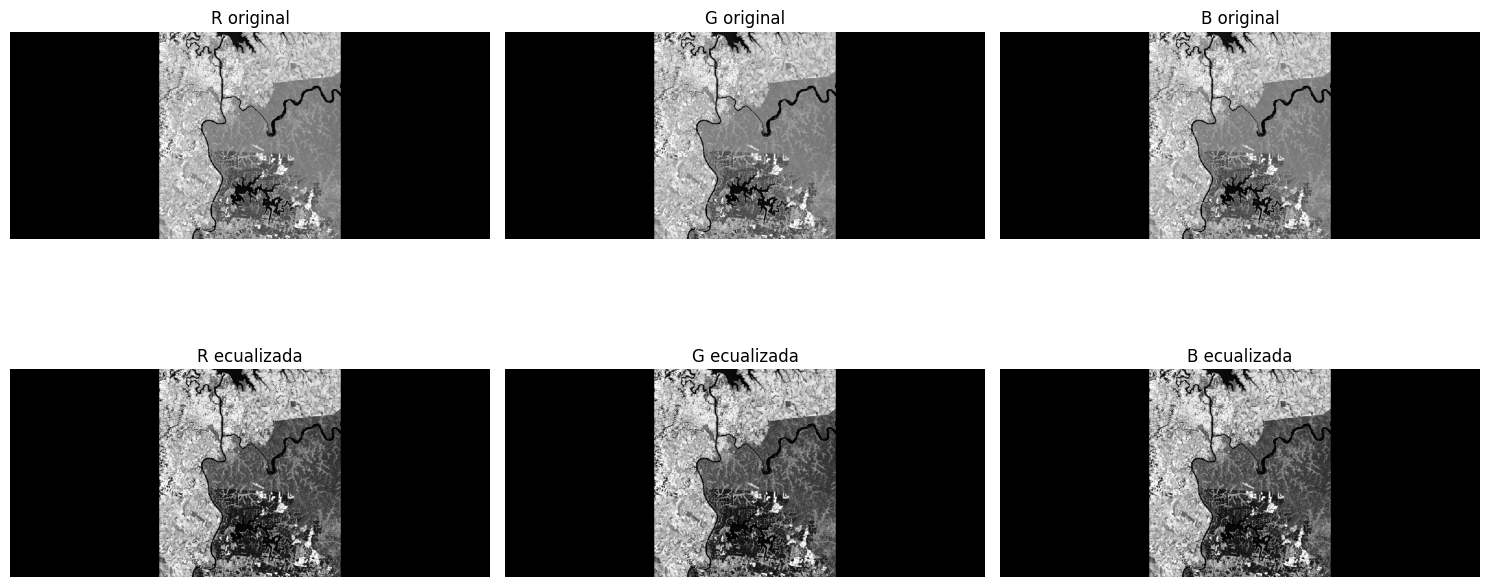

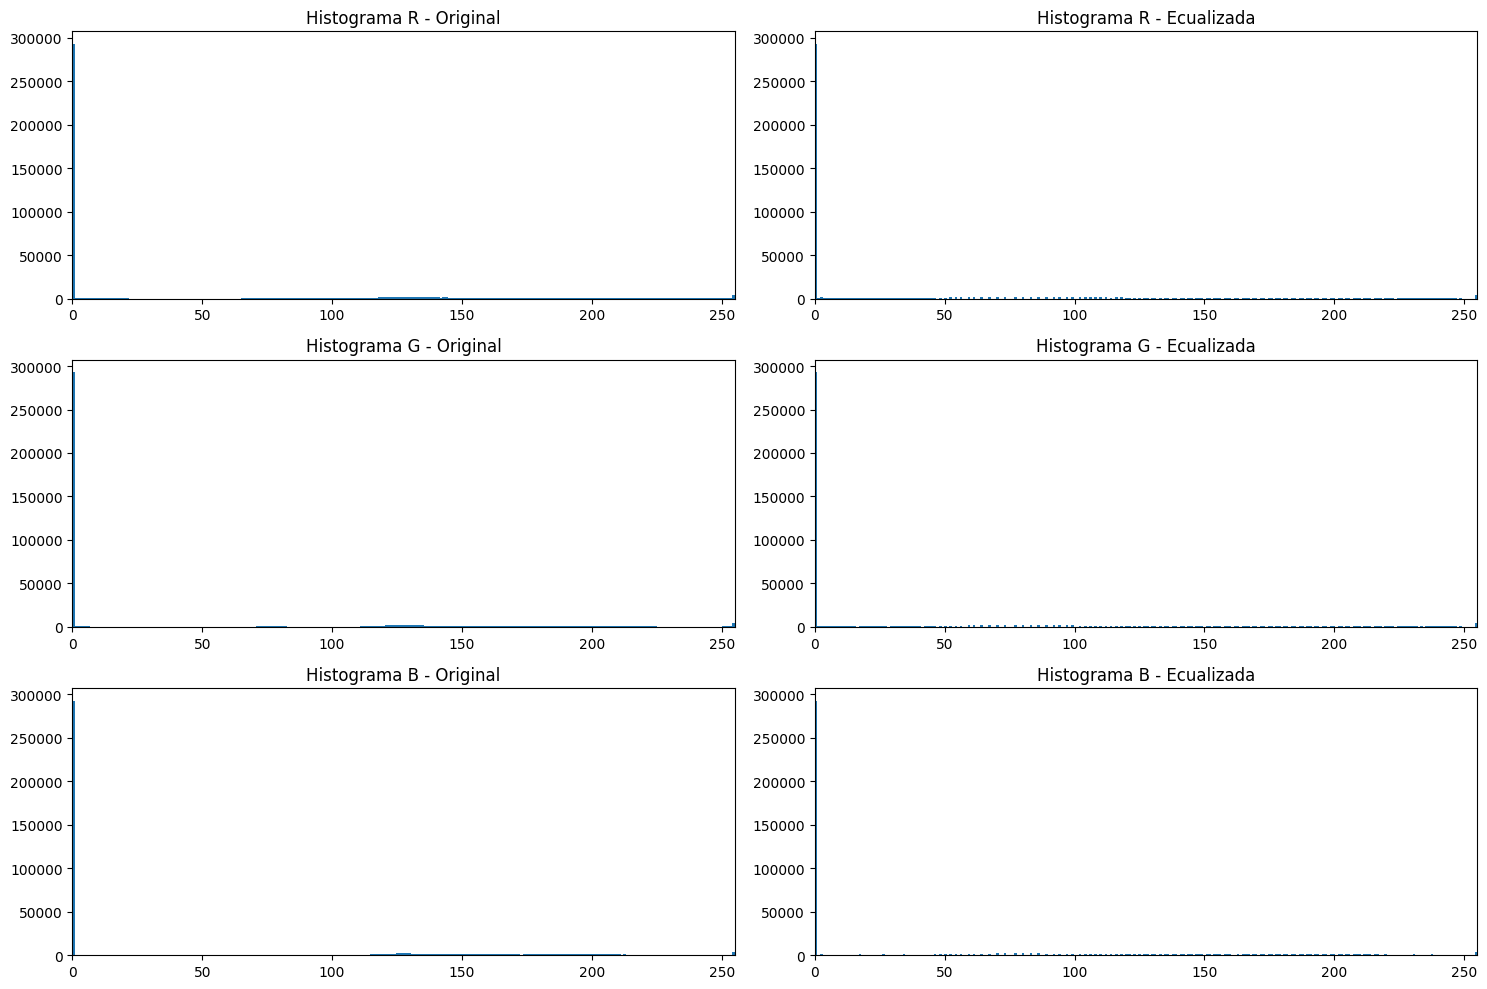

Imagen ecualizada guardada como:
swir1_ecualizada_rgb.jpg


In [9]:
# ============================================================
# 7. ECUALIZACIÓN DEL HISTOGRAMA BANDA POR BANDA
# ============================================================

# ------------------------------------------------------------
# 1. Función de ecualización del histograma
# ------------------------------------------------------------

def ecualizar_histograma(banda):

    # Convertir la banda a matriz NumPy
    datos = np.array(banda)

    # Calcular el histograma
    histograma = np.bincount(datos.ravel(), minlength=256)

    # Calcular la función de distribución acumulada (CDF)
    cdf = histograma.cumsum()

    # Eliminar los valores de CDF que sean cero
    cdf_min = cdf[cdf > 0].min()

    # Número total de píxeles
    total_pixeles = datos.size

    # Crear tabla de transformación
    tabla = ((cdf - cdf_min) * 255 /
             (total_pixeles - cdf_min))

    # Asegurar valores válidos
    tabla = np.clip(tabla, 0, 255).astype(np.uint8)

    # Aplicar la transformación
    resultado = tabla[datos]

    # Convertir nuevamente a imagen
    return Image.fromarray(resultado)


# ------------------------------------------------------------
# 2. Separar las bandas RGB
# ------------------------------------------------------------

R = img.getchannel("R")
G = img.getchannel("G")
B = img.getchannel("B")


# ------------------------------------------------------------
# 3. Ecualizar cada banda por separado
# ------------------------------------------------------------

R_ecualizada = ecualizar_histograma(R)
G_ecualizada = ecualizar_histograma(G)
B_ecualizada = ecualizar_histograma(B)


# ------------------------------------------------------------
# 4. Combinar las bandas ecualizadas
# ------------------------------------------------------------

img_ecualizada = Image.merge(
    "RGB",
    (R_ecualizada, G_ecualizada, B_ecualizada)
)


# ------------------------------------------------------------
# 5. Mostrar imagen original y ecualizada
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Imagen RGB original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_ecualizada)
plt.title("Imagen RGB ecualizada")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Mostrar cada banda original y ecualizada
# ------------------------------------------------------------

plt.figure(figsize=(15, 8))

# R
plt.subplot(2, 3, 1)
plt.imshow(R, cmap="gray")
plt.title("R original")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(R_ecualizada, cmap="gray")
plt.title("R ecualizada")
plt.axis("off")

# G
plt.subplot(2, 3, 2)
plt.imshow(G, cmap="gray")
plt.title("G original")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(G_ecualizada, cmap="gray")
plt.title("G ecualizada")
plt.axis("off")

# B
plt.subplot(2, 3, 3)
plt.imshow(B, cmap="gray")
plt.title("B original")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(B_ecualizada, cmap="gray")
plt.title("B ecualizada")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Comparar histogramas antes y después
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

# Banda R
plt.subplot(3, 2, 1)
plt.hist(np.array(R).ravel(), bins=256, range=(0, 255))
plt.title("Histograma R - Original")
plt.xlim(0, 255)

plt.subplot(3, 2, 2)
plt.hist(np.array(R_ecualizada).ravel(), bins=256, range=(0, 255))
plt.title("Histograma R - Ecualizada")
plt.xlim(0, 255)

# Banda G
plt.subplot(3, 2, 3)
plt.hist(np.array(G).ravel(), bins=256, range=(0, 255))
plt.title("Histograma G - Original")
plt.xlim(0, 255)

plt.subplot(3, 2, 4)
plt.hist(np.array(G_ecualizada).ravel(), bins=256, range=(0, 255))
plt.title("Histograma G - Ecualizada")
plt.xlim(0, 255)

# Banda B
plt.subplot(3, 2, 5)
plt.hist(np.array(B).ravel(), bins=256, range=(0, 255))
plt.title("Histograma B - Original")
plt.xlim(0, 255)

plt.subplot(3, 2, 6)
plt.hist(np.array(B_ecualizada).ravel(), bins=256, range=(0, 255))
plt.title("Histograma B - Ecualizada")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Guardar resultado
# ------------------------------------------------------------

img_ecualizada.save("swir1_ecualizada_rgb.jpg")

print("Imagen ecualizada guardada como:")
print("swir1_ecualizada_rgb.jpg")

## 8. Aplicar la ecualización del histograma por segunda vez a la misma imagen. Observar el resultado y dar una explicación de lo sucedido.

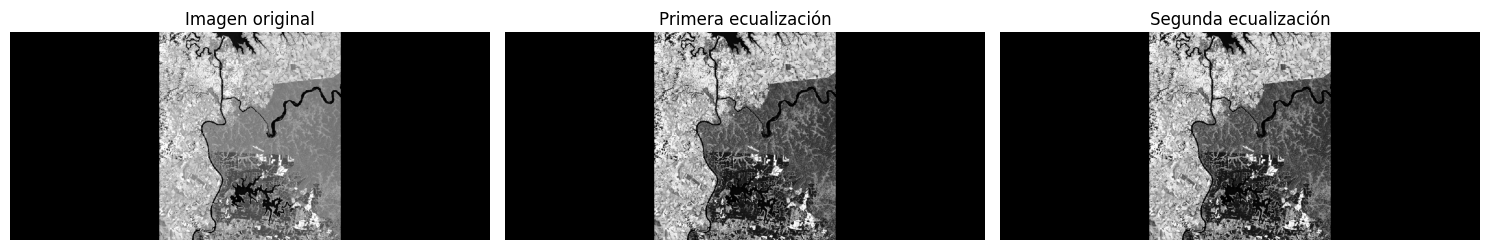

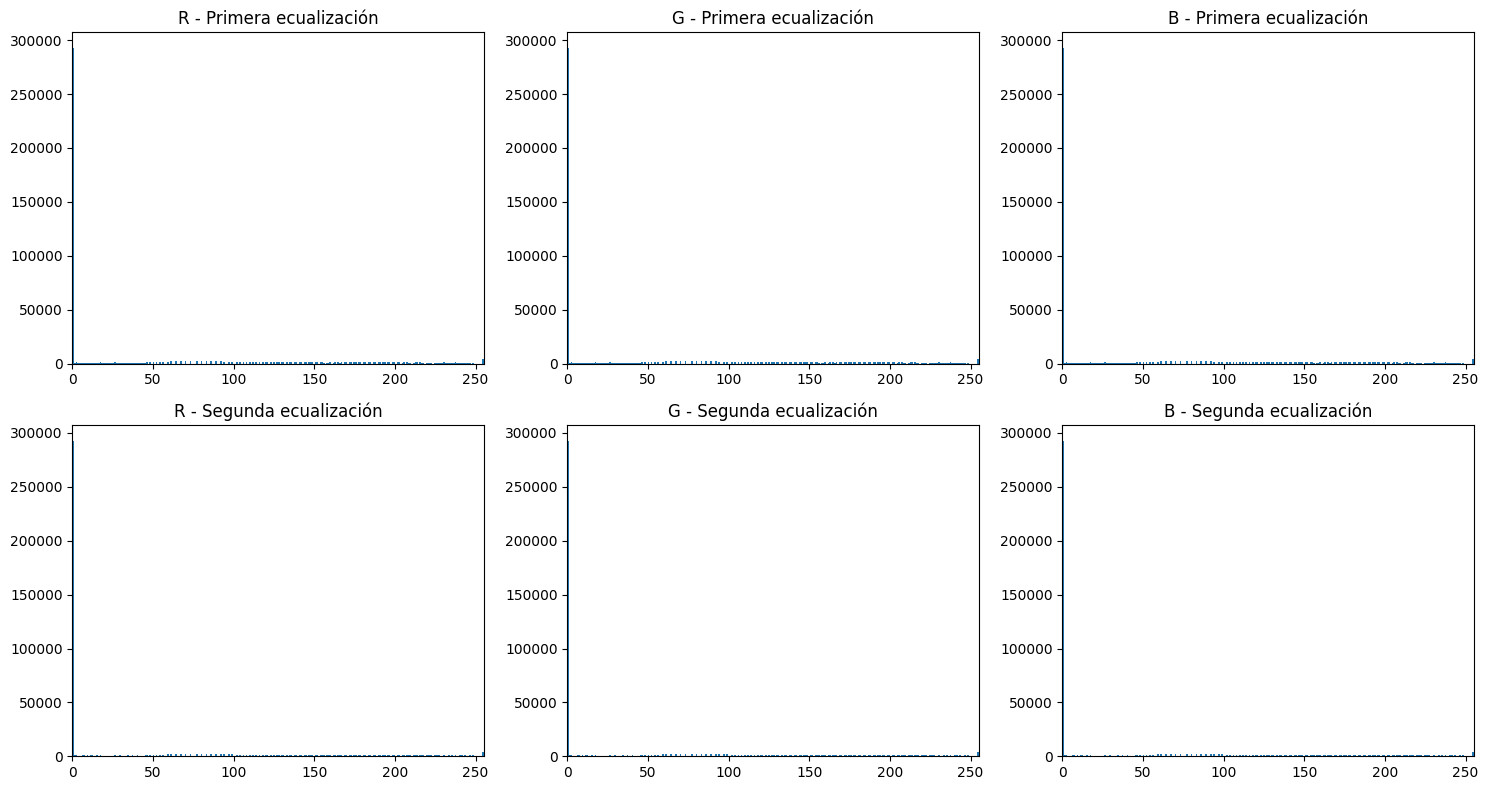

Segunda ecualización guardada como:
swir1_ecualizada_segunda_vez.jpg


In [10]:
# ============================================================
# 8. SEGUNDA ECUALIZACIÓN DEL HISTOGRAMA
# ============================================================

# ------------------------------------------------------------
# 1. Función de ecualización del histograma
# ------------------------------------------------------------

def ecualizar_histograma(banda):

    datos = np.array(banda)

    # Histograma de 256 niveles
    histograma = np.bincount(datos.ravel(), minlength=256)

    # Función de distribución acumulada
    cdf = histograma.cumsum()

    # Primer valor distinto de cero
    cdf_min = cdf[cdf > 0].min()

    # Número total de píxeles
    total_pixeles = datos.size

    # Tabla de transformación
    if total_pixeles == cdf_min:
        tabla = np.arange(256)
    else:
        tabla = ((cdf - cdf_min) * 255 /
                 (total_pixeles - cdf_min))

    tabla = np.clip(tabla, 0, 255).astype(np.uint8)

    # Aplicar transformación
    resultado = tabla[datos]

    return Image.fromarray(resultado)


# ------------------------------------------------------------
# 2. Tomar la imagen ecualizada del punto 7
# ------------------------------------------------------------

# Si todavía tienes img_ecualizada en memoria, usamos esa.
# Si no, descomenta la siguiente línea:

# img_ecualizada = Image.open("swir1_ecualizada_rgb.jpg").convert("RGB")


# ------------------------------------------------------------
# 3. Separar las bandas de la primera ecualización
# ------------------------------------------------------------

R_1 = img_ecualizada.getchannel("R")
G_1 = img_ecualizada.getchannel("G")
B_1 = img_ecualizada.getchannel("B")


# ------------------------------------------------------------
# 4. Aplicar una segunda ecualización
# ------------------------------------------------------------

R_2 = ecualizar_histograma(R_1)
G_2 = ecualizar_histograma(G_1)
B_2 = ecualizar_histograma(B_1)


# ------------------------------------------------------------
# 5. Combinar nuevamente las bandas
# ------------------------------------------------------------

img_ecualizada_2 = Image.merge(
    "RGB",
    (R_2, G_2, B_2)
)


# ------------------------------------------------------------
# 6. Mostrar los resultados
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_ecualizada)
plt.title("Primera ecualización")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_ecualizada_2)
plt.title("Segunda ecualización")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Comparar histogramas
# ------------------------------------------------------------

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.hist(np.array(R_1).ravel(), bins=256, range=(0, 255))
plt.title("R - Primera ecualización")
plt.xlim(0, 255)

plt.subplot(2, 3, 2)
plt.hist(np.array(G_1).ravel(), bins=256, range=(0, 255))
plt.title("G - Primera ecualización")
plt.xlim(0, 255)

plt.subplot(2, 3, 3)
plt.hist(np.array(B_1).ravel(), bins=256, range=(0, 255))
plt.title("B - Primera ecualización")
plt.xlim(0, 255)

plt.subplot(2, 3, 4)
plt.hist(np.array(R_2).ravel(), bins=256, range=(0, 255))
plt.title("R - Segunda ecualización")
plt.xlim(0, 255)

plt.subplot(2, 3, 5)
plt.hist(np.array(G_2).ravel(), bins=256, range=(0, 255))
plt.title("G - Segunda ecualización")
plt.xlim(0, 255)

plt.subplot(2, 3, 6)
plt.hist(np.array(B_2).ravel(), bins=256, range=(0, 255))
plt.title("B - Segunda ecualización")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Guardar la segunda ecualización
# ------------------------------------------------------------

img_ecualizada_2.save("swir1_ecualizada_segunda_vez.jpg")

print("Segunda ecualización guardada como:")
print("swir1_ecualizada_segunda_vez.jpg")

###### Explicación: Al aplicar la ecualización del histograma por segunda vez, la imagen presenta cambios mucho menores respecto a la primera ecualización. Esto ocurre porque la primera aplicación ya redistribuyó los niveles de intensidad de cada banda y aumentó el contraste utilizando el rango disponible de 0 a 255. Al realizar nuevamente la misma transformación, la distribución de los niveles ya se encuentra relativamente extendida, por lo que la segunda ecualización produce un efecto reducido. En algunos casos pueden aparecer pequeñas diferencias debido a la cuantización de los valores de intensidad a 8 bits.

## 9. Implementar los siguientes puntos para agregar ruido a una imagen.

Imagen cargada correctamente.
Tamaño de la imagen: (451, 1042, 3)

        PARÁMETROS DEL RUIDO

--------------------------------------------
       RUIDO GAUSSIANO ADITIVO
--------------------------------------------

--------------------------------------------
     RUIDO EXPONENCIAL MULTIPLICATIVO
--------------------------------------------


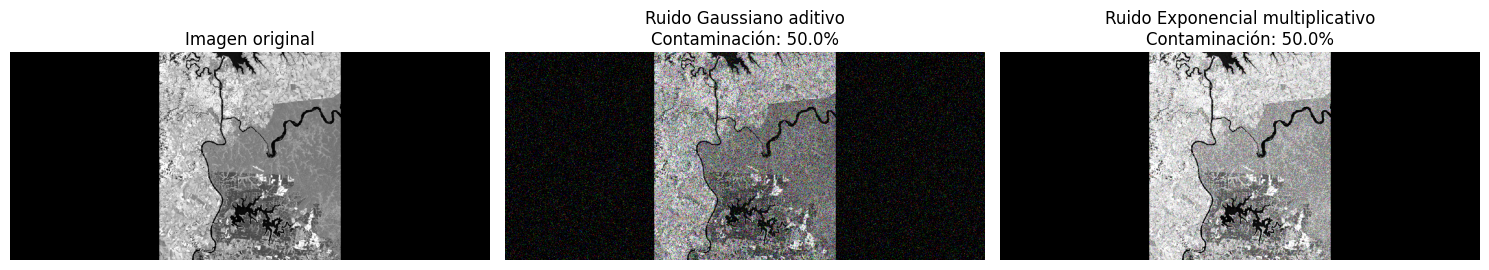


              RESULTADOS
Porcentaje de contaminación: 50.00%
Media Gaussiana: -50.0
Desviación estándar Gaussiana: 100.0
Lambda Exponencial: 2.0

Imágenes guardadas correctamente:
1. swir1_ruido_gaussiano.jpg
2. swir1_ruido_exponencial.jpg


In [11]:
# ============================================================
# 9. AGREGAR RUIDO A UNA IMAGEN
#
# a) Ruido Gaussiano aditivo
# b) Ruido Exponencial multiplicativo
#
# El porcentaje de contaminación y los parámetros
# de los generadores son datos de entrada.
# ============================================================

# Convertir imagen a matriz NumPy
img_array = np.array(img).astype(np.float32)

print("Imagen cargada correctamente.")
print("Tamaño de la imagen:", img_array.shape)


# ============================================================
# 1. DATOS DE ENTRADA
# ============================================================

print("\n============================================")
print("        PARÁMETROS DEL RUIDO")
print("============================================")


# ------------------------------------------------------------
# PORCENTAJE DE CONTAMINACIÓN
# Rango: 1 - 100 %
# ------------------------------------------------------------

while True:

    try:
        porcentaje = float(
            input(
                "\nIngrese el porcentaje de contaminación [1-100]: "
            )
        )

        if 1 <= porcentaje <= 100:
            break

        print(
            "Error: el porcentaje debe estar entre 1 y 100."
        )

    except ValueError:

        print(
            "Error: ingrese un número válido."
        )


# Convertir porcentaje a decimal
porcentaje_decimal = porcentaje / 100


# ============================================================
# 2. PARÁMETROS DEL RUIDO GAUSSIANO
# ============================================================

print("\n--------------------------------------------")
print("       RUIDO GAUSSIANO ADITIVO")
print("--------------------------------------------")


# ------------------------------------------------------------
# MEDIA
# Rango: -50 a 50
# ------------------------------------------------------------

while True:

    try:
        media_gauss = float(
            input(
                "Ingrese la media Gaussiana [-50 a 50]: "
            )
        )

        if -50 <= media_gauss <= 50:
            break

        print(
            "Error: la media debe estar entre -50 y 50."
        )

    except ValueError:

        print(
            "Error: ingrese un número válido."
        )


# ------------------------------------------------------------
# DESVIACIÓN ESTÁNDAR
# Rango: 1 a 100
# ------------------------------------------------------------

while True:

    try:
        desv_gauss = float(
            input(
                "Ingrese la desviación estándar [1-100]: "
            )
        )

        if 1 <= desv_gauss <= 100:
            break

        print(
            "Error: la desviación debe estar entre 1 y 100."
        )

    except ValueError:

        print(
            "Error: ingrese un número válido."
        )


# ============================================================
# 3. PARÁMETRO DEL RUIDO EXPONENCIAL
# ============================================================

print("\n--------------------------------------------")
print("     RUIDO EXPONENCIAL MULTIPLICATIVO")
print("--------------------------------------------")


# ------------------------------------------------------------
# LAMBDA
# Rango: 0.01 a 5
# ------------------------------------------------------------

while True:

    try:
        lambda_exp = float(
            input(
                "Ingrese Lambda [0.01-5]: "
            )
        )

        if 0.01 <= lambda_exp <= 5:
            break

        print(
            "Error: Lambda debe estar entre 0.01 y 5."
        )

    except ValueError:

        print(
            "Error: ingrese un número válido."
        )


# ============================================================
# 4. FUNCIÓN DE RUIDO GAUSSIANO ADITIVO
# ============================================================

def ruido_gaussiano_aditivo(
    imagen,
    porcentaje,
    media,
    desviacion
):

    # Copiar imagen original
    resultado = imagen.copy()

    # Obtener dimensiones
    alto, ancho, bandas = resultado.shape

    # Número de píxeles que serán contaminados
    cantidad = int(
        alto * ancho * porcentaje
    )

    # Seleccionar posiciones aleatorias
    indices = np.random.choice(
        alto * ancho,
        cantidad,
        replace=False
    )

    # Convertir índices a coordenadas
    filas = indices // ancho
    columnas = indices % ancho

    # Generar ruido Gaussiano
    ruido = np.random.normal(
        loc=media,
        scale=desviacion,
        size=(cantidad, bandas)
    )

    # Agregar ruido
    resultado[
        filas,
        columnas,
        :
    ] += ruido

    # Limitar valores al rango 0-255
    resultado = np.clip(
        resultado,
        0,
        255
    )

    return resultado.astype(np.uint8)


# ============================================================
# 5. FUNCIÓN DE RUIDO EXPONENCIAL MULTIPLICATIVO
# ============================================================

def ruido_exponencial_multiplicativo(
    imagen,
    porcentaje,
    lambda_exp
):

    # Copiar imagen original
    resultado = imagen.copy()

    # Obtener dimensiones
    alto, ancho, bandas = resultado.shape

    # Número de píxeles que serán contaminados
    cantidad = int(
        alto * ancho * porcentaje
    )

    # Seleccionar posiciones aleatorias
    indices = np.random.choice(
        alto * ancho,
        cantidad,
        replace=False
    )

    # Convertir índices a coordenadas
    filas = indices // ancho
    columnas = indices % ancho

    # Generar ruido exponencial
    ruido = np.random.exponential(
        scale=1 / lambda_exp,
        size=(cantidad, bandas)
    )

    # Crear factor multiplicativo
    factor = 1 + ruido

    # Aplicar ruido
    resultado[
        filas,
        columnas,
        :
    ] *= factor

    # Limitar valores al rango 0-255
    resultado = np.clip(
        resultado,
        0,
        255
    )

    return resultado.astype(np.uint8)


# ============================================================
# 6. APLICAR RUIDO GAUSSIANO
# ============================================================

img_gaussiano = ruido_gaussiano_aditivo(
    img_array,
    porcentaje_decimal,
    media_gauss,
    desv_gauss
)


# ============================================================
# 7. APLICAR RUIDO EXPONENCIAL
# ============================================================

img_exponencial = ruido_exponencial_multiplicativo(
    img_array,
    porcentaje_decimal,
    lambda_exp
)


# ============================================================
# 8. MOSTRAR RESULTADOS
# ============================================================

plt.figure(figsize=(15, 5))


# Imagen original
plt.subplot(1, 3, 1)

plt.imshow(img)

plt.title(
    "Imagen original"
)

plt.axis("off")


# Ruido Gaussiano
plt.subplot(1, 3, 2)

plt.imshow(img_gaussiano)

plt.title(
    f"Ruido Gaussiano aditivo\n"
    f"Contaminación: {porcentaje:.1f}%"
)

plt.axis("off")


# Ruido Exponencial
plt.subplot(1, 3, 3)

plt.imshow(img_exponencial)

plt.title(
    f"Ruido Exponencial multiplicativo\n"
    f"Contaminación: {porcentaje:.1f}%"
)

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 9. MOSTRAR INFORMACIÓN DE LOS PARÁMETROS
# ============================================================

print("\n============================================")
print("              RESULTADOS")
print("============================================")

print(
    f"Porcentaje de contaminación: {porcentaje:.2f}%"
)

print(
    f"Media Gaussiana: {media_gauss}"
)

print(
    f"Desviación estándar Gaussiana: {desv_gauss}"
)

print(
    f"Lambda Exponencial: {lambda_exp}"
)


# ============================================================
# 10. GUARDAR LAS IMÁGENES
# ============================================================

Image.fromarray(
    img_gaussiano
).save(
    "swir1_ruido_gaussiano.jpg"
)

Image.fromarray(
    img_exponencial
).save(
    "swir1_ruido_exponencial.jpg"
)

print("\nImágenes guardadas correctamente:")

print(
    "1. swir1_ruido_gaussiano.jpg"
)

print(
    "2. swir1_ruido_exponencial.jpg"
)

## 10. Implementar un generador de ruido Sal y Pimienta y aplicarlo una imagen.

Imagen cargada correctamente.
Tamaño de la imagen: (451, 1042, 3)

       PARÁMETROS SAL Y PIMIENTA


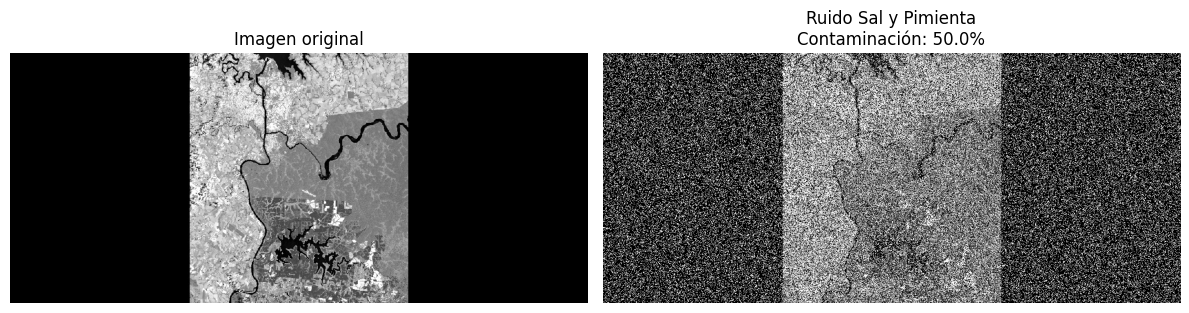

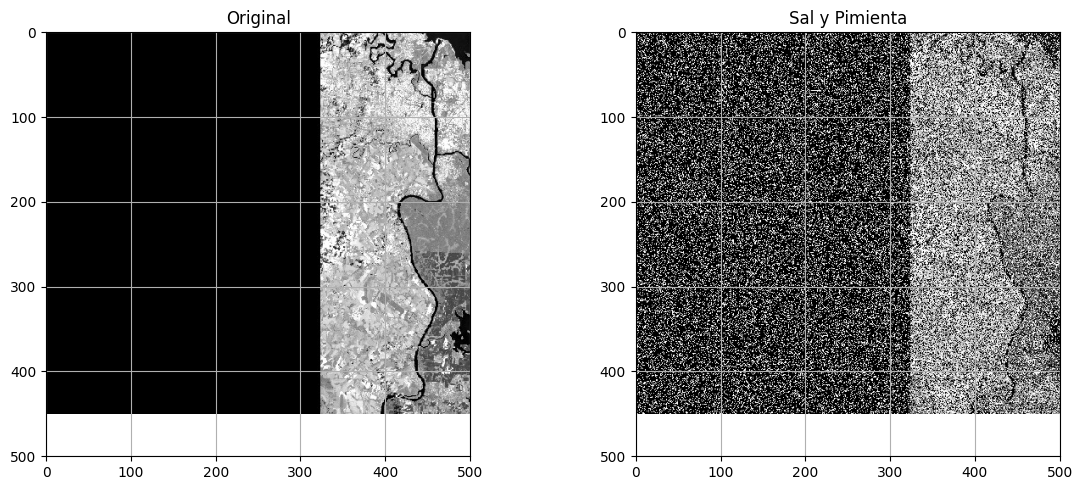


RESULTADO
Porcentaje de contaminación: 50.00%
Porcentaje de Sal: 45.00%
Porcentaje de Pimienta: 55.00%

Imagen guardada como:
swir1_ruido_sal_pimienta.jpg


In [12]:
# ============================================================
# 10. GENERADOR DE RUIDO SAL Y PIMIENTA
# ============================================================

# Convertir a matriz NumPy
img_array = np.array(img).copy()

print("Imagen cargada correctamente.")
print("Tamaño de la imagen:", img_array.shape)


# ============================================================
# 1. FUNCIÓN DE RUIDO SAL Y PIMIENTA
# ============================================================

def ruido_sal_pimienta(
    imagen,
    porcentaje,
    porcentaje_sal=0.5
):
    """
    Genera ruido Sal y Pimienta.

    Parámetros:
        imagen          -> imagen RGB como matriz NumPy
        porcentaje      -> porcentaje total de píxeles contaminados
        porcentaje_sal  -> proporción de píxeles que serán SAL

    Retorna:
        imagen con ruido Sal y Pimienta
    """

    # Copiar imagen original
    resultado = imagen.copy()

    # Obtener dimensiones
    alto, ancho, bandas = resultado.shape

    # Cantidad total de píxeles
    total_pixeles = alto * ancho

    # Cantidad de píxeles a contaminar
    cantidad = int(
        total_pixeles * porcentaje
    )

    # Seleccionar posiciones aleatorias
    indices = np.random.choice(
        total_pixeles,
        cantidad,
        replace=False
    )

    # Determinar cuántos serán SAL
    cantidad_sal = int(
        cantidad * porcentaje_sal
    )

    # El resto serán PIMIENTA
    cantidad_pimienta = cantidad - cantidad_sal

    # Separar índices
    indices_sal = indices[:cantidad_sal]

    indices_pimienta = indices[cantidad_sal:]

    # Convertir índices a coordenadas
    filas_sal = indices_sal // ancho
    columnas_sal = indices_sal % ancho

    filas_pimienta = indices_pimienta // ancho
    columnas_pimienta = indices_pimienta % ancho

    # --------------------------------------------------------
    # SAL = BLANCO
    # --------------------------------------------------------

    resultado[
        filas_sal,
        columnas_sal,
        :
    ] = 255

    # --------------------------------------------------------
    # PIMIENTA = NEGRO
    # --------------------------------------------------------

    resultado[
        filas_pimienta,
        columnas_pimienta,
        :
    ] = 0

    return resultado


# ============================================================
# 2. DATOS DE ENTRADA
# ============================================================

print("\n============================================")
print("       PARÁMETROS SAL Y PIMIENTA")
print("============================================")


# ------------------------------------------------------------
# Porcentaje total de contaminación
# Rango: 1 - 100 %
# ------------------------------------------------------------

while True:

    try:

        porcentaje = float(
            input(
                "Ingrese el porcentaje de contaminación [1-100]: "
            )
        )

        if 1 <= porcentaje <= 100:
            break

        print(
            "Error: el porcentaje debe estar entre 1 y 100."
        )

    except ValueError:

        print(
            "Error: ingrese un número válido."
        )


# Convertir a decimal
porcentaje_decimal = porcentaje / 100


# ------------------------------------------------------------
# Porcentaje de SAL
# Rango: 0 - 100 %
# ------------------------------------------------------------

while True:

    try:

        porcentaje_sal = float(
            input(
                "Ingrese el porcentaje de SAL [0-100]: "
            )
        )

        if 0 <= porcentaje_sal <= 100:
            break

        print(
            "Error: el porcentaje debe estar entre 0 y 100."
        )

    except ValueError:

        print(
            "Error: ingrese un número válido."
        )


# Convertir a decimal
porcentaje_sal_decimal = porcentaje_sal / 100


# ============================================================
# 3. APLICAR RUIDO SAL Y PIMIENTA
# ============================================================

img_ruido = ruido_sal_pimienta(
    img_array,
    porcentaje_decimal,
    porcentaje_sal_decimal
)


# ============================================================
# 4. MOSTRAR RESULTADOS
# ============================================================

plt.figure(figsize=(12, 5))


# Imagen original
plt.subplot(1, 2, 1)

plt.imshow(img)

plt.title(
    "Imagen original"
)

plt.axis("off")


# Imagen con ruido
plt.subplot(1, 2, 2)

plt.imshow(img_ruido)

plt.title(
    f"Ruido Sal y Pimienta\n"
    f"Contaminación: {porcentaje:.1f}%"
)

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 5. MOSTRAR LA IMAGEN CON ZOOM
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(img)

plt.title("Original")

plt.xlim(0, 500)
plt.ylim(500, 0)

plt.grid()


plt.subplot(1, 2, 2)

plt.imshow(img_ruido)

plt.title("Sal y Pimienta")

plt.xlim(0, 500)
plt.ylim(500, 0)

plt.grid()

plt.tight_layout()

plt.show()


# ============================================================
# 6. GUARDAR RESULTADO
# ============================================================

Image.fromarray(
    img_ruido
).save(
    "swir1_ruido_sal_pimienta.jpg"
)

print("\n============================================")
print("RESULTADO")
print("============================================")

print(
    f"Porcentaje de contaminación: {porcentaje:.2f}%"
)

print(
    f"Porcentaje de Sal: {porcentaje_sal:.2f}%"
)

print(
    f"Porcentaje de Pimienta: "
    f"{100 - porcentaje_sal:.2f}%"
)

print(
    "\nImagen guardada como:"
)

print(
    "swir1_ruido_sal_pimienta.jpg"
)

## 11. Dada una imagen satelital óptica separada en bandas, calcular los índices NDVI, NDWI y SVI y mostrarlos como imágenes.

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


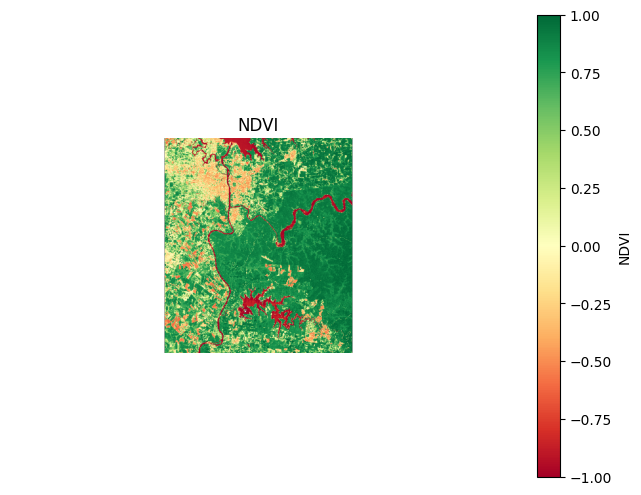

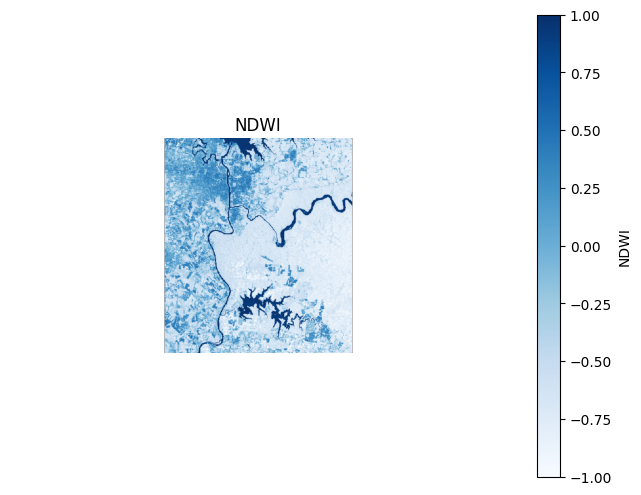

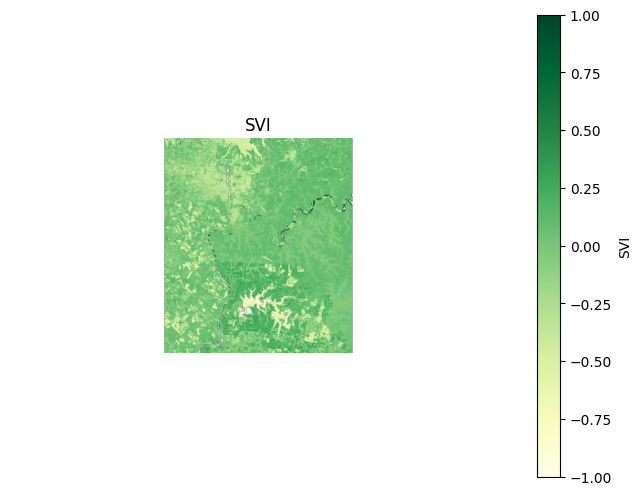

In [13]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# URLs RAW de GitHub
url_green = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales/main/LC08_224-078_2018-01-05_green.tif"
url_red = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales/main/LC08_224-078_2018-01-05_red.tif"
url_nir = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales/main/LC08_224-078_2018-01-05_nir.tif"
url_swir1 = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales/main/LC08_224-078_2018-01-05_swir1.tif"


def leer_banda(url):
    with rasterio.open(url) as src:
        return src.read(1).astype("float32")


green = leer_banda(url_green)
red   = leer_banda(url_red)
nir   = leer_banda(url_nir)
swir1 = leer_banda(url_swir1)


# Evitar división entre cero
np.seterr(divide="ignore", invalid="ignore")


# NDVI
ndvi = (nir - red) / (nir + red)

# NDWI
ndwi = (green - nir) / (green + nir)

# SVI
svi = (nir - swir1) / (nir + swir1)


# Valores inválidos
ndvi[~np.isfinite(ndvi)] = np.nan
ndwi[~np.isfinite(ndwi)] = np.nan
svi[~np.isfinite(svi)] = np.nan


# ============================================================
# VISUALIZACIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_title("NDVI")
ax.axis("off")
plt.colorbar(im, ax=ax, label="NDVI")

plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
ax.set_title("NDWI")
ax.axis("off")
plt.colorbar(im, ax=ax, label="NDWI")

plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(svi, cmap="YlGn", vmin=-1, vmax=1)
ax.set_title("SVI")
ax.axis("off")
plt.colorbar(im, ax=ax, label="SVI")

plt.show()

## 12. Contestar las siguientes preguntas teóricas:

#### a) Dado un pixel (x, y), definir la 8-vecindad del pixel en función de sus coordenadas. ¿Por qué es importante la vecindad?

#### b) De la definición de histograma. ¿Para qué sirve estudiar el histograma de una imagen?

#### c) ¿Qué es una banda de una imagen? ¿Cuántas bandas tiene una imagen satelital óptica?

##### R// a) Dado un píxel (x, y), definir la 8-vecindad del píxel en función de sus coordenadas. ¿Por qué es importante la vecindad?

La 8-vecindad de un píxel son los 8 píxeles que están alrededor de él. Si el píxel es \((x,y)\), sus vecinos son los que están arriba, abajo, a la izquierda, a la derecha y en las cuatro esquinas.

La vecindad es importante porque permite conocer la relación que existe entre un píxel y los píxeles que están cerca de él. Esto sirve para detectar bordes, formas, regiones y también para reducir ruido en una imagen.

##### R// b) De la definición de histograma. ¿Para qué sirve estudiar el histograma de una imagen?

El histograma muestra cómo están distribuidos los valores de los píxeles de una imagen.

Estudiarlo sirve principalmente para conocer el brillo y el contraste de la imagen. También permite saber si una imagen está muy oscura, muy clara o si tiene poco contraste.

##### R// c) ¿Qué es una banda de una imagen? ¿Cuántas bandas tiene una imagen satelital óptica?

Una banda es una parte de la imagen que representa un rango específico de luz o radiación. Cada banda permite observar diferentes características de la superficie.

El número de bandas depende del satélite que se utilice. Por ejemplo, Landsat 8 tiene 11 bandas que trabajan con diferentes partes del espectro electromagnético.